# ORCC year 2 growth analysis

### This analysis examines oyster growth from the end of august phase 2 (2024) until august the following year (2025) in response to phase 1 and phase 2 treatments

In [1]:
#load packages
library(lme4) #for linear mixed effects model
library(readr) #to read in data
library(tidyr)
library(emmeans) #for post hocs
library(esquisse) #interface for building plots
library(dplyr) #for data wrangling
library(nlme) #for linear mixed effects model
library(car) #for the Levene test
library(ggplot2) #for graphs
library(plotrix) #for standard error
library(performance) #model testing
library(lmtest) #another option than levene test for variance

Loading required package: Matrix


Attaching package: ‘tidyr’


The following objects are masked from ‘package:Matrix’:

    expand, pack, unpack


Warning message:
“package ‘emmeans’ was built under R version 4.4.3”
Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'

Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘nlme’


The following object is masked from ‘package:dplyr’:

    collapse


The following object is masked from ‘package:lme4’:

    lmList


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Loading required package: zoo


Attach

In [2]:
#set contrasts ALWAYS RUN
options(contrasts = c("contr.sum","contr.poly")) #could also be contr.treatment for unequal groups sum
getOption("contrasts")

[1] "contr.sum"  "contr.poly"

In [4]:
getwd()
setwd("/Users/sophiemontague/Desktop/MontagueORCC_repo/MontagueORCC/Oyster_Weight_Data")

Year2_Growth <- read_csv("/Users/sophiemontague/Desktop/MontagueORCC_repo/MontagueORCC/Year_2_Data/growth_YEAR2_weights_merged.csv", 
                             col_types = cols(Phase_1_temp = col_factor(), 
                                              Phase_1_DO =col_factor(), 
                                              Phase_2.1_temp =col_factor(), 
                                              Phase_2.1_DO=col_factor(), 
                                              Phase_1_rep =col_factor(), 
                                              Phase_2_rep =col_factor(),
                                              Phase_1_treat = col_factor(),
                                              Phase_2_treat = col_factor(),
                                              Phase_2_rep_R = col_factor(),
                                              Phase_1_rep_R = col_factor(),
                                              double_single_dead_year2 = col_factor()))

[1] "/Users/sophiemontague/Desktop/MontagueORCC_repo/MontagueORCC"

New names:
• `` -> `...1`


In [5]:
Year2_Growth_clean <- Year2_Growth %>%
  drop_na(Actual_tissue_growth_year2_mg) %>%
  filter(Exclude_year2 != "Y" | is.na(Exclude_year2)) %>%
  filter(!is.na(Phase_1_treat) & Phase_1_treat != "NA") %>%
  mutate(
    Actual_tissue_growth_year2_mg = as.numeric(Actual_tissue_growth_year2_mg),
    Actual_shell_growth_year2_mg = as.numeric(Actual_shell_growth_year2_mg),
    Ratio_TS_year2 = as.numeric(Ratio_TS_year2))

head(Year2_Growth_clean)

...1,Sample_Name,Phase_1_DO,Phase_1_temp,Phase_2.1_DO,Phase_2.1_temp,Phase_1_treat,Phase_2_treat,Phase_1_rep_R,Phase_2_rep_R,⋯,Submerged_weight_year2,Dry_weight_year2,double_single_dead_year2,Notes_year2,Actual_shell_year2_mg,Actual_tissue_year2_mg,Actual_shell_growth_year2_mg,Actual_tissue_growth_year2_mg,Ratio_TS_year2,Exclude_year2
<dbl>,<chr>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,⋯,<dbl>,<dbl>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
2,2024_Both01_Both02_O14,Hyp,Warm,Hyp,Warm,Both,Both,Both01,Both02,⋯,517.1,1309.3,NA,NA,816.4478,492.8522,161.0318,125.96822,0.7822569,NA
3,2024_Both01_Both03_O26,Hyp,Warm,Hyp,Warm,Both,Both,Both01,Both03,⋯,797.2,1828.7,NA,NA,1259.9582,568.7418,799.4587,368.54134,0.4609886,NA
4,2024_Both01_Both05_O49,Hyp,Warm,Hyp,Warm,Both,Both,Both01,Both05,⋯,726.4,1811.5,NA,NA,1147.8535,663.6465,529.3306,334.26938,0.6314945,NA
5,2024_Both01_Both05_O50,Hyp,Warm,Hyp,Warm,Both,Both,Both01,Both05,⋯,726.2,1682.6,NA,NA,1147.5368,535.0632,437.3351,181.36492,0.4147047,NA
6,2024_Both01_Both06_O61,Hyp,Warm,Hyp,Warm,Both,Both,Both01,Both06,⋯,346.2,799.6,NA,NA,545.8448,253.7552,254.6107,57.48928,0.2257928,NA
8,2024_Both01_Cont02_O13,Hyp,Warm,Norm,Ambient,Both,Cont,Both01,Cont02,⋯,1309.1,3109.3,NA,NA,2070.5006,1038.7994,929.1391,566.36088,0.6095544,NA


# 1. Tissue Growth

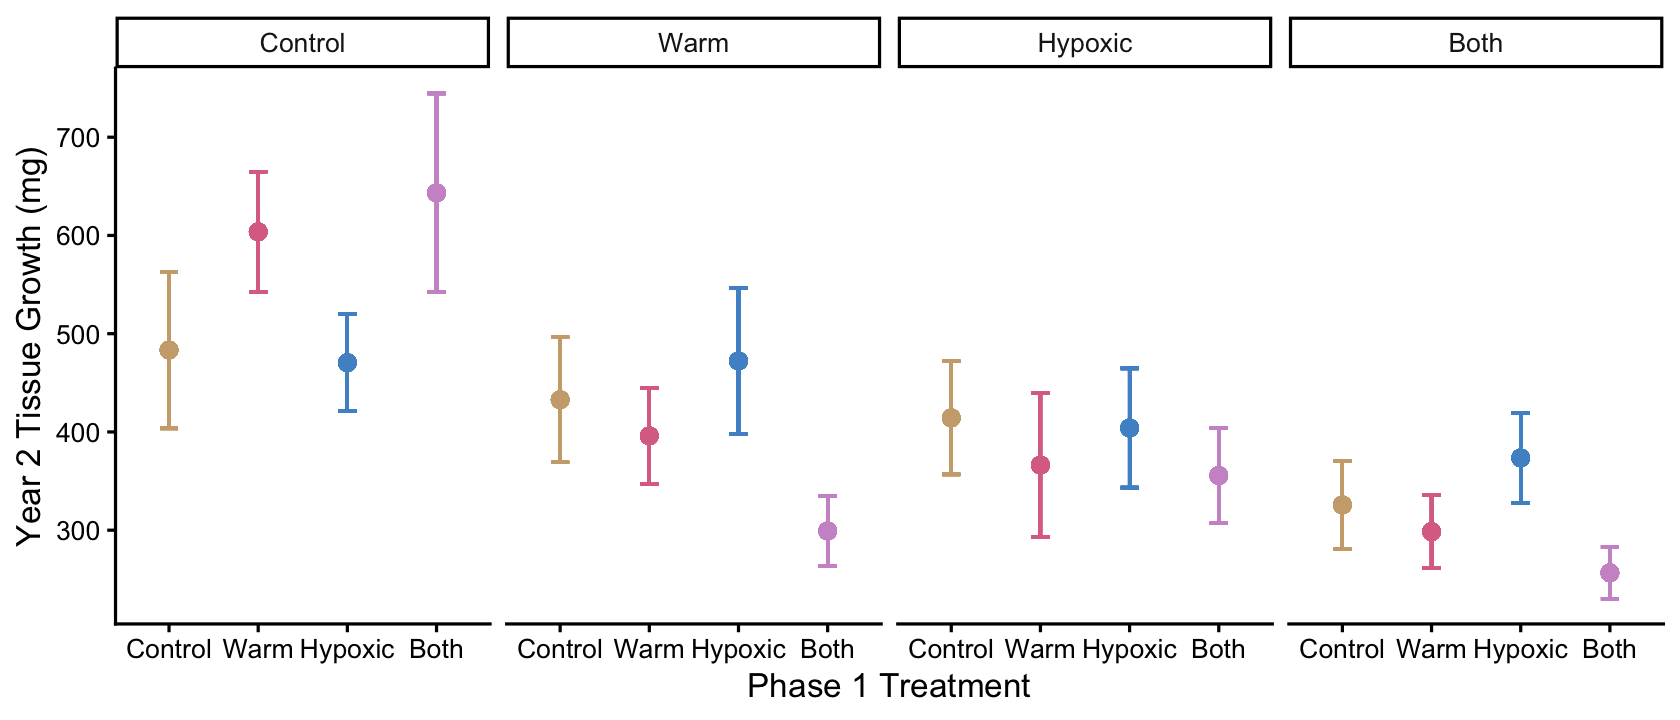

In [6]:
#format for jupyter
options(repr.plot.width = 14, repr.plot.height = 6)

#all, TISSUE
summary_stats_t <- Year2_Growth_clean %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(Actual_tissue_growth_year2_mg, na.rm = TRUE),
    se_growth = std.error(Actual_tissue_growth_year2_mg, na.rm = TRUE))

  #reorder Phase_1_treat and Phase_2_treat
  summary_stats_t$Phase_1_treat <- factor(summary_stats_t$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
  summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
  
  #plot with mean and SD, TISSUE
  ggplot(summary_stats_t, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
    geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
    geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                  width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
    theme_classic(base_size = 20) +
    guides(color = "none") + # Remove legend for color
    facet_wrap(vars(Phase_2_treat), 
               labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
               scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
    scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
    labs(x = "Phase 1 Treatment", y = "Year 2 Tissue Growth (mg)") +
    scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
    theme(legend.position = "none") # Remove legend

In [14]:
##tissue growth (mg)
m1 <- lmer(Actual_tissue_growth_year2_mg~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Year2_Growth_clean, REML=TRUE)
aov_tab <- Anova(m1, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),125.97939863,1,19.498259,0.0000
Phase_1_DO,0.07811728,1,9.668258,0.7858
Phase_1_temp,0.60760628,1,9.691794,0.4543
Phase_2.1_temp,1.98004682,1,19.717533,0.1750
Phase_2.1_DO,2.80547777,1,19.719094,0.1097
Phase_1_DO:Phase_1_temp,0.61110683,1,9.744911,0.4529
Phase_1_DO:Phase_2.1_temp,0.11537460,1,18.765695,0.7379
Phase_1_temp:Phase_2.1_temp,6.91763395,1,18.816840,0.0166
Phase_1_DO:Phase_2.1_DO,0.01171423,1,18.779308,0.9150


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,1.251771,0.2295028
,457,NA,NA


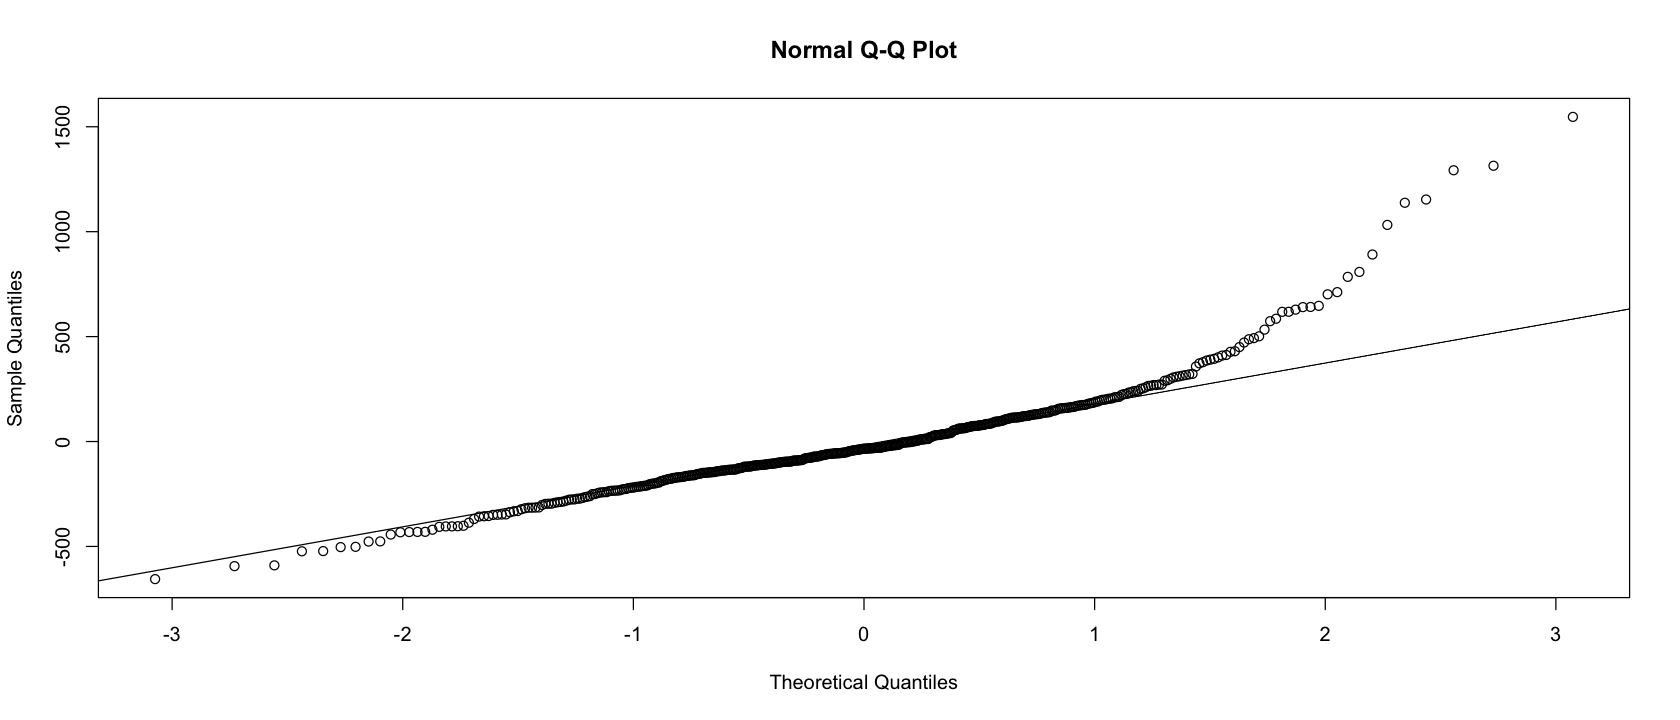

In [15]:
#diagnostics
leveneTest(Actual_tissue_year2_mg~Phase_1_treat*Phase_2_treat, Year2_Growth_clean) 
m1.e <- residuals(m1) 
qqnorm(m1.e)
qqline(m1.e)

In [16]:
#posthocs
emmeans(m1,specs = pairwise ~ Phase_1_temp*Phase_2.1_temp, adjust = "none")
emmeans(m1,specs = pairwise ~ Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_temp Phase_2.1_temp emmean   SE   df lower.CL upper.CL
 Warm         Warm              314 54.0 23.5      203      426
 Ambient      Warm              403 54.0 23.4      292      515
 Warm         Ambient           485 55.3 24.6      371      599
 Ambient      Ambient           437 56.0 25.8      322      553

Results are averaged over the levels of: Phase_1_DO, Phase_2.1_DO 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                       estimate   SE   df t.ratio p.value
 Warm Warm - Ambient Warm          -88.8 35.9 14.8  -2.473  0.0260
 Warm Warm - Warm Ambient         -171.0 77.2 24.3  -2.215  0.0364
 Warm Warm - Ambient Ambient      -123.1 77.8 24.6  -1.583  0.1263
 Ambient Warm - Warm Ambient       -82.2 77.3 24.0  -1.063  0.2982
 Ambient Warm - Ambient Ambient    -34.3 77.7 24.9  -0.442  0.6623
 Warm Ambient - Ambient Ambient     47.8 38.0 16.1   1.260  0.2255

Results are averaged over the levels of: Phase_1_D

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_temp Phase_2.1_temp Phase_2.1_DO emmean   SE   df lower.CL upper.CL
 Warm         Warm           Hyp             279 76.5 23.9      121      437
 Ambient      Warm           Hyp             348 76.1 23.4      191      505
 Warm         Ambient        Hyp             362 76.6 24.1      204      520
 Ambient      Ambient        Hyp             407 77.6 25.2      247      567
 Warm         Warm           Norm            350 76.2 23.6      193      507
 Ambient      Warm           Norm            458 76.5 23.9      300      616
 Warm         Ambient        Norm            608 79.7 25.5      444      773
 Ambient      Ambient        Norm            468 80.7 26.7      302      634

Results are averaged over the levels of: Phase_1_DO 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                                   estimate    SE   df t.ratio p.value
 Warm Warm Hyp - Ambient Warm Hyp             -69.18  50.6 17.2  -1.367  0.1891
 

### plotting significant interactions

In [ ]:
 Warm Warm - Ambient Warm          -88.8 35.9 14.8  -2.473  0.0260
 Warm Warm - Warm Ambient         -171.0 77.2 24.3  -2.215  0.0364

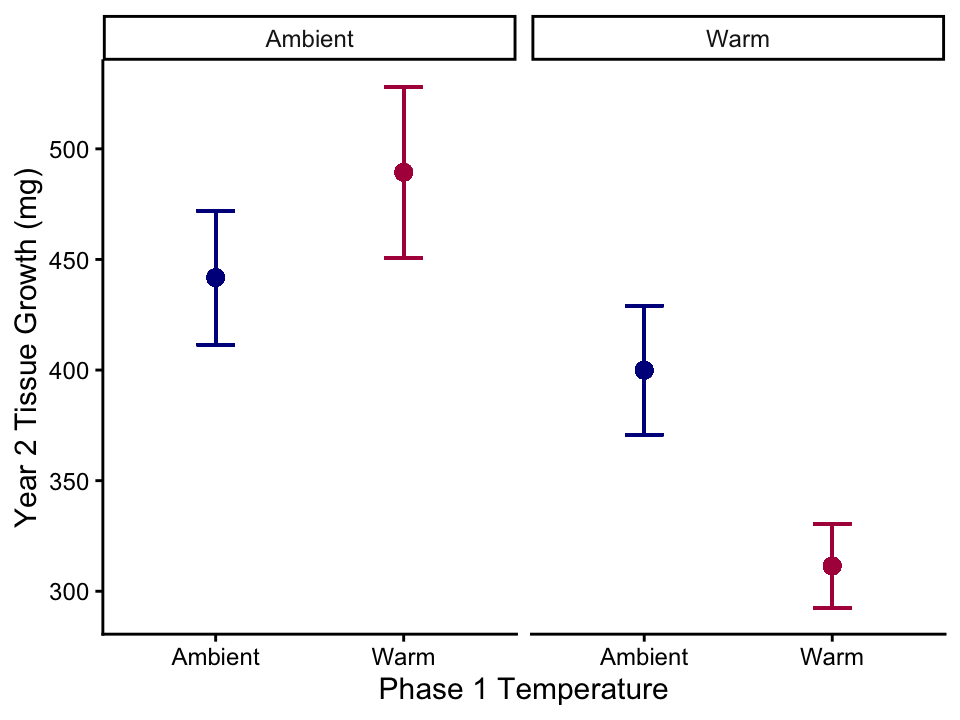

In [10]:
#format display for jupyter
options(repr.plot.width = 8, repr.plot.height = 6)

summary_stats_t <- Year2_Growth_clean %>%
  filter(!is.na(Actual_tissue_growth_year2_mg)) %>%
  group_by(Phase_1_temp, Phase_2.1_temp) %>%
  mutate(
    mean_growth = mean(Actual_tissue_growth_year2_mg, na.rm = TRUE),
    se_growth = std.error(Actual_tissue_growth_year2_mg, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_temp <- factor(summary_stats_t$Phase_1_temp, 
                                        levels = c("Ambient", "Warm"))
summary_stats_t$Phase_2.1_temp <- factor(summary_stats_t$Phase_2.1_temp, 
                                        levels = c("Ambient", "Warm"))

ggplot(summary_stats_t, aes(x = Phase_1_temp, y = mean_growth, color = Phase_1_temp)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(vars(Phase_2.1_temp), 
             labeller = as_labeller(c("Warm" = "Warm", "Ambient" = "Ambient")), 
             scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
  scale_color_manual(values = c("Warm" = "#B00149", "Ambient" = "darkblue")) +
  labs(x = "Phase 1 Temperature", y = "Year 2 Tissue Growth (mg)") +
  theme(legend.position = "none") # Remove legend


### Oysters grew less tissue when exposed to warming twice than once in either phase (p = 0.01)

More time exposed = more acclimated to those conditions AND/OR more certain about those environments after experiencing them twice.


Then the environment for the next 9 months was control conditions, an environmental mismatch from the warm temperatures they experienced, and they performed much worse.

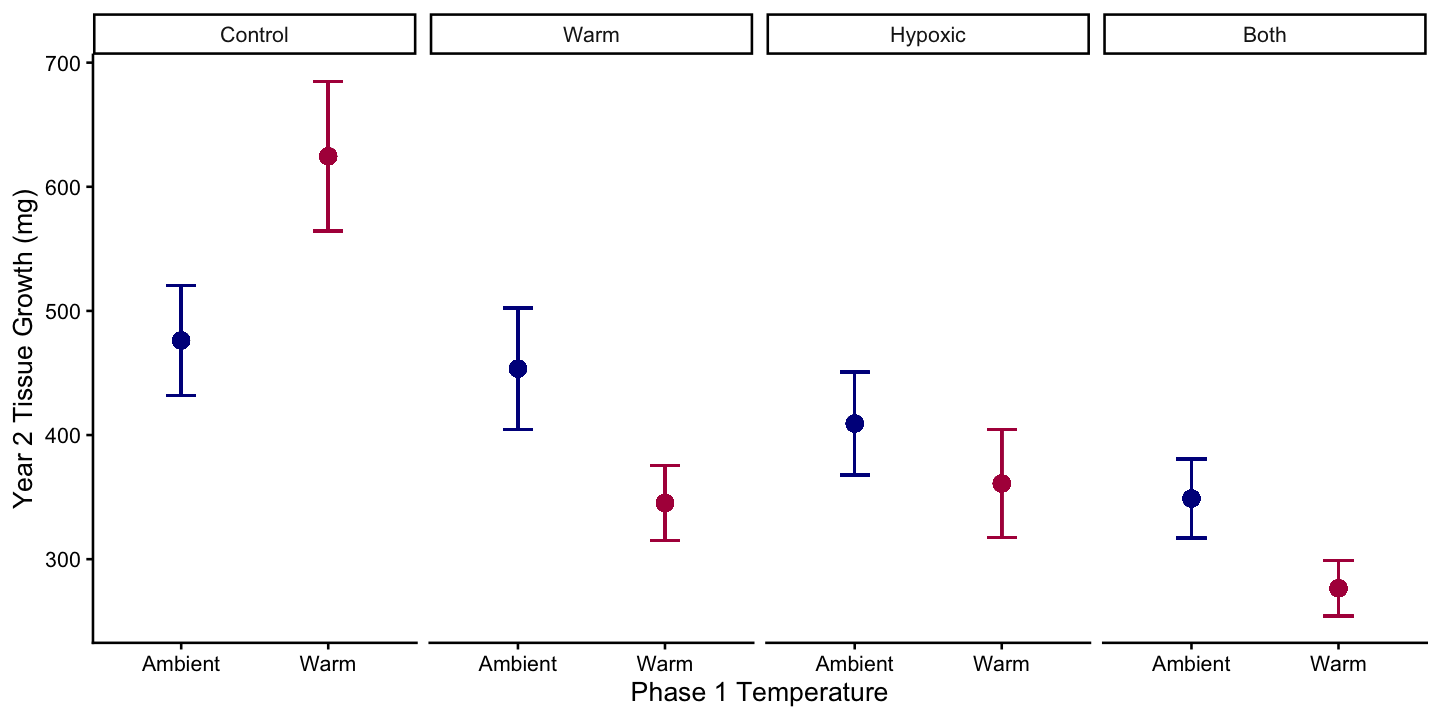

In [13]:
#format display for jupyter
options(repr.plot.width = 12, repr.plot.height = 6)

# plot Phase_1_temp:Phase_2.1_temp:Phase_2.1_DO tissue  year 2 
summary_stats_t <- Year2_Growth_clean%>%
  group_by(Phase_1_temp, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(Actual_tissue_growth_year2_mg, na.rm = TRUE),
    se_growth = std.error(Actual_tissue_growth_year2_mg, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_t$Phase_1_temp <- factor(summary_stats_t$Phase_1_temp, 
                                       levels = c("Ambient", "Warm"))
summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp",  "Both"))

#plot with mean and SD
ggplot(summary_stats_t, aes(x = Phase_1_temp, y = mean_growth, color = Phase_1_temp)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 16) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(
    vars(Phase_2_treat),
    labeller = as_labeller(c(
      "Hyp" = "Hypoxic",
      "Cont" = "Control",
      "Warm" = "Warm",
      "Both" = "Both")), scales = "fixed", nrow = 1) +
  scale_color_manual(values = c("Warm" = "#B00149", "Ambient" = "darkblue")) +
  labs(x = "Phase 1 Temperature", y = "Year 2 Tissue Growth (mg)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
  theme(legend.position = "none") # Remove legend

In [14]:
#Warm control comparisons

#Warm Warm Hyp - Warm Ambient Norm           p =  0.0063
#    warm both - warm control

#Ambient Warm Hyp - Warm Ambient Norm        p = 0.0263
#    ambient both - warm control

#            Warm control grew more tissue than oysters in both phase 2

#Warm Ambient Hyp - Warm Ambient Norm        p = 0.0350
#    warm hyp - warm control

#Warm Warm Norm - Warm Ambient Norm          p = 0.0273
#    warm warm - warm control

#            oysters that experienced early life warming performed better 
#            after experiencing control phase 2 conditions than warm or hypoxic phase 2 conditions

#Warm Ambient Norm - Ambient Ambient Norm    p = 0.0187
#    warm control - ambient control

#            oysters that experienced early life warming grew more tissue in control conditions over the next year

In [16]:

#Warm Warm Norm - Ambient Warm Norm          p = 0.0469
#    warm warm - ambient warm

#            oysters grew less tissue when exposed to warming twice than once in either phase 

#Also \/ repeated from above supports this
#Warm Warm Norm - Warm Ambient Norm          p = 0.0273
#    warm warm - warm control

# 2. Shell Growth

In [ ]:
m2 <- lmer(Actual_shell_growth_year2_mg~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Year2_Growth_clean, REML=TRUE)
Anova(m2, test="F", type="III")

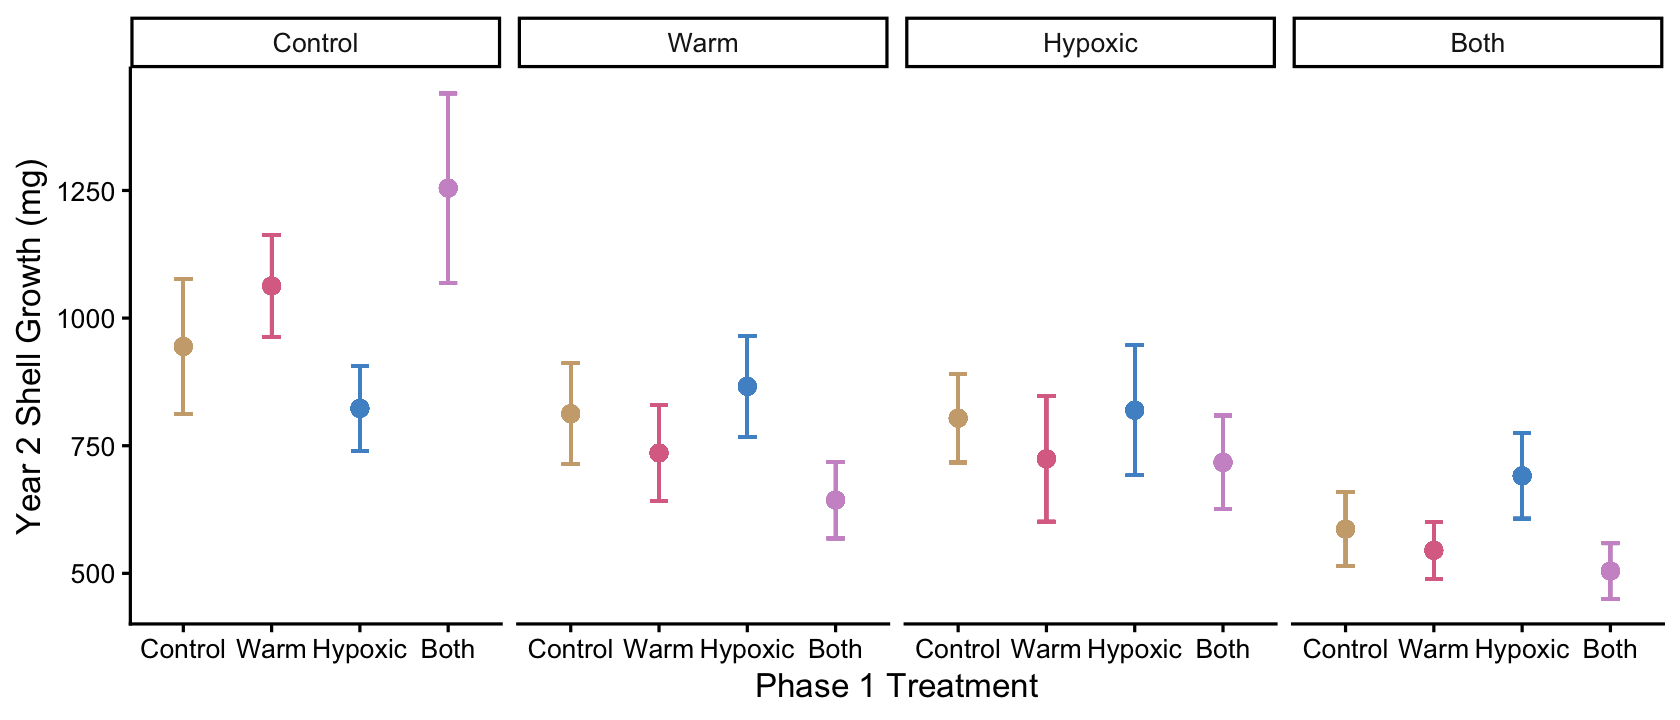

In [17]:
#format for jupyter
options(repr.plot.width = 14, repr.plot.height = 6)

#all, TISSUE
summary_stats_s <- Year2_Growth_clean %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(Actual_shell_growth_year2_mg, na.rm = TRUE),
    se_growth = std.error(Actual_shell_growth_year2_mg, na.rm = TRUE))

  #reorder Phase_1_treat and Phase_2_treat
  summary_stats_s$Phase_1_treat <- factor(summary_stats_s$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
  summary_stats_s$Phase_2_treat <- factor(summary_stats_s$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
  
  #plot with mean and SD, TISSUE
  ggplot(summary_stats_s, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
    geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
    geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                  width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
    theme_classic(base_size = 20) +
    guides(color = "none") + # Remove legend for color
    facet_wrap(vars(Phase_2_treat), 
               labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
               scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
    scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
    labs(x = "Phase 1 Treatment", y = "Year 2 Shell Growth (mg)") +
    scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
    theme(legend.position = "none") # Remove legend

## statistical analysis

In [18]:
m2 <- lmer(log(Actual_shell_growth_year2_mg)~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Year2_Growth_clean, REML=TRUE)
aov_tab<-Anova(m2, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),4.916910e+03,1,19.441325,0.0000
Phase_1_DO,8.749062e-03,1,9.658786,0.9274
Phase_1_temp,4.588245e-01,1,12.316596,0.5107
Phase_2.1_temp,2.748809e+00,1,19.690207,0.1132
Phase_2.1_DO,3.484354e+00,1,19.692298,0.0769
Phase_1_DO:Phase_1_temp,1.463281e-01,1,9.712867,0.7103
Phase_1_DO:Phase_2.1_temp,2.310815e-01,1,18.767845,0.6363
Phase_1_temp:Phase_2.1_temp,2.227788e-01,1,18.983693,0.6423
Phase_1_DO:Phase_2.1_DO,1.268691e-01,1,18.783494,0.7257


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,1.395772,0.1446627
,457,NA,NA


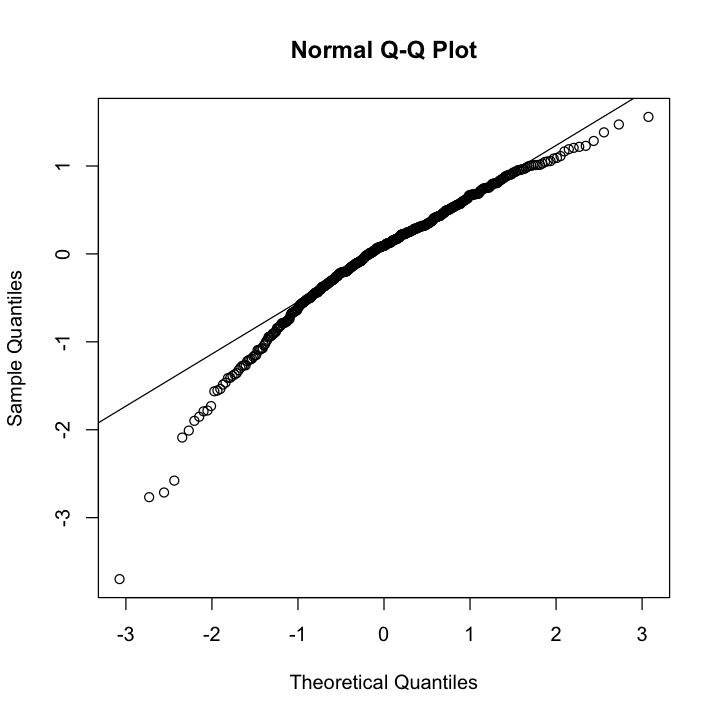

In [19]:
#format for jupyter
options(repr.plot.width = 6, repr.plot.height = 6)

#diagnostics
leveneTest(log(Actual_shell_growth_year2_mg)~Phase_1_treat*Phase_2_treat, Year2_Growth_clean) 
m1.e <- residuals(m2) 
qqnorm(m1.e)
qqline(m1.e)

In [20]:
#posthocs
emmeans(m2,specs = pairwise ~ Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO, adjust = "none")

#could also do 
#emmeans(m2,specs = pairwise ~ Phase_2.1_DO, adjust = "none")
#emmeans(m2,specs = pairwise ~ Phase_2.1_temp*Phase_2.1_DO, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_temp Phase_2.1_temp Phase_2.1_DO emmean    SE   df lower.CL upper.CL
 Warm         Warm           Hyp            6.09 0.195 25.9     5.69     6.49
 Ambient      Warm           Hyp            6.09 0.194 25.3     5.69     6.49
 Warm         Ambient        Hyp            6.21 0.195 26.1     5.81     6.61
 Ambient      Ambient        Hyp            6.47 0.198 27.4     6.07     6.88
 Warm         Warm           Norm           6.29 0.194 25.5     5.89     6.69
 Ambient      Warm           Norm           6.47 0.195 25.9     6.07     6.87
 Warm         Ambient        Norm           6.84 0.204 27.5     6.43     7.26
 Ambient      Ambient        Norm           6.62 0.207 28.9     6.19     7.04

Results are averaged over the levels of: Phase_1_DO 
Degrees-of-freedom method: kenward-roger 
Results are given on the log (not the response) scale. 
Confidence level used: 0.95 

$contrasts
 contrast                                   estimate    SE   df t.ratio p.value
 Warm Warm Hyp -

## plotting significant interactions

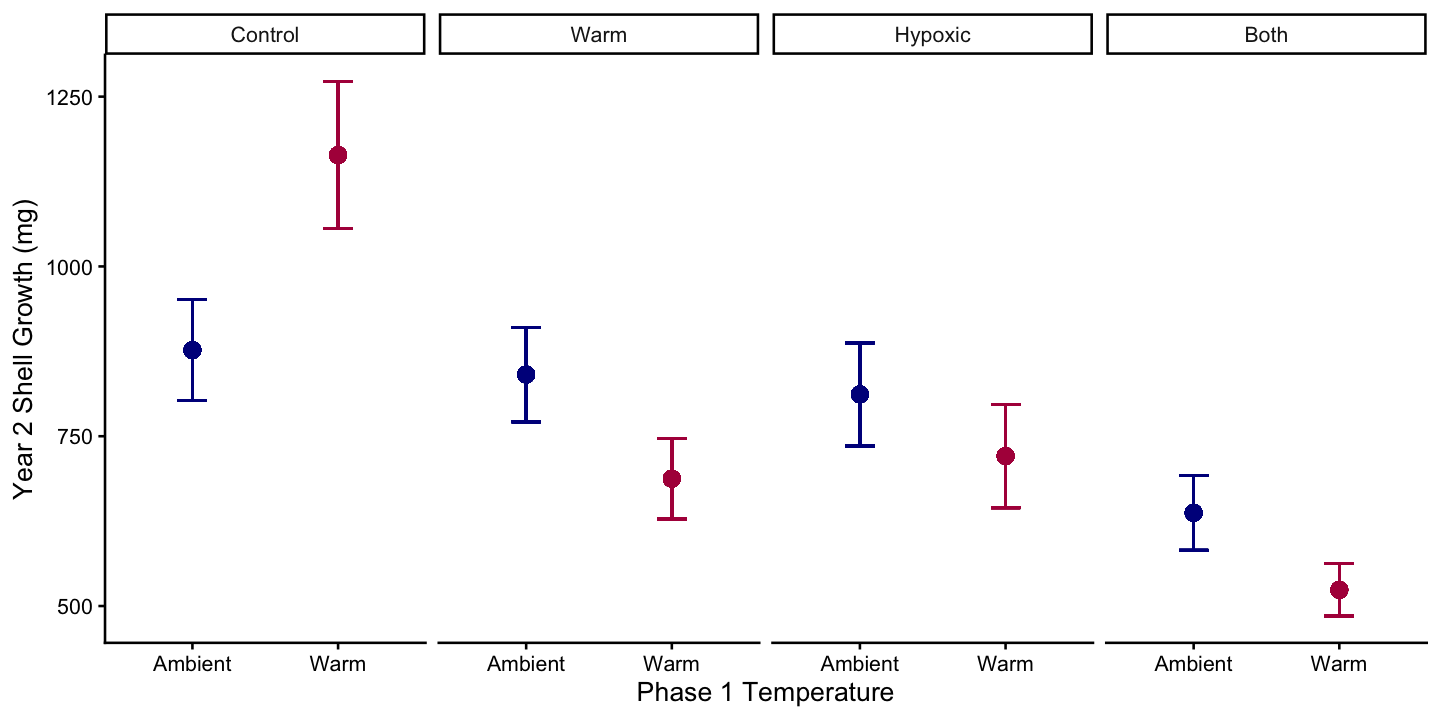

In [28]:
#format for jupyter
options(repr.plot.width = 12, repr.plot.height = 6)

# plot Phase_1_temp:Phase_2.1_temp:Phase_2.1_DO shell  year 2 
summary_stats_s <- Year2_Growth_clean%>%
  group_by(Phase_1_temp, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(Actual_shell_growth_year2_mg, na.rm = TRUE),
    se_growth = std.error(Actual_shell_growth_year2_mg, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_s$Phase_1_temp <- factor(summary_stats_s$Phase_1_temp, 
                                       levels = c("Ambient", "Warm"))
summary_stats_s$Phase_2_treat <- factor(summary_stats_s$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp",  "Both"))

#plot with mean and SD
ggplot(summary_stats_s, aes(x = Phase_1_temp, y = mean_growth, color = Phase_1_temp)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 16) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(
    vars(Phase_2_treat),
    labeller = as_labeller(c(
      "Hyp" = "Hypoxic",
      "Cont" = "Control",
      "Warm" = "Warm",
      "Both" = "Both")), scales = "fixed", nrow = 1) +
  scale_color_manual(values = c("Warm" = "#B00149", "Ambient" = "darkblue")) +
  labs(x = "Phase 1 Temperature", y = "Year 2 Shell Growth (mg)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
  theme(legend.position = "none") # Remove legend

In [ ]:
#Warm Warm Hyp - Warm Ambient Norm          p = 0.0127
#    warm both - warm control
#Ambient Warm Hyp - Warm Ambient Norm       p = 0.0125
#    ambient both - warm control
            
#            oysters exposed to early life warming and then control conditions 
#            grew more than oysters that experienced both stressors in phase 2

#Warm Ambient Hyp - Warm Ambient Norm       p = 0.0340
#    warm hyp - warm control
#            oysters exposed to early life warming grew more after experiencing phase 2 control conditions than phase 2 hypoxia

#and maaayyyybeeee
# Warm Warm Norm - Warm Ambient Norm         p = 0.0597
#    warm warm - warm control
#        oysters exposed to early life warming grew less after being exposed to warming again

# 3. Tissue:Shell Growth

### Below is all experimental, found no significant results from normal analysis

In [22]:
low_TS <- Year2_Growth_clean%>%
filter(Ratio_TS_year2 < 7)


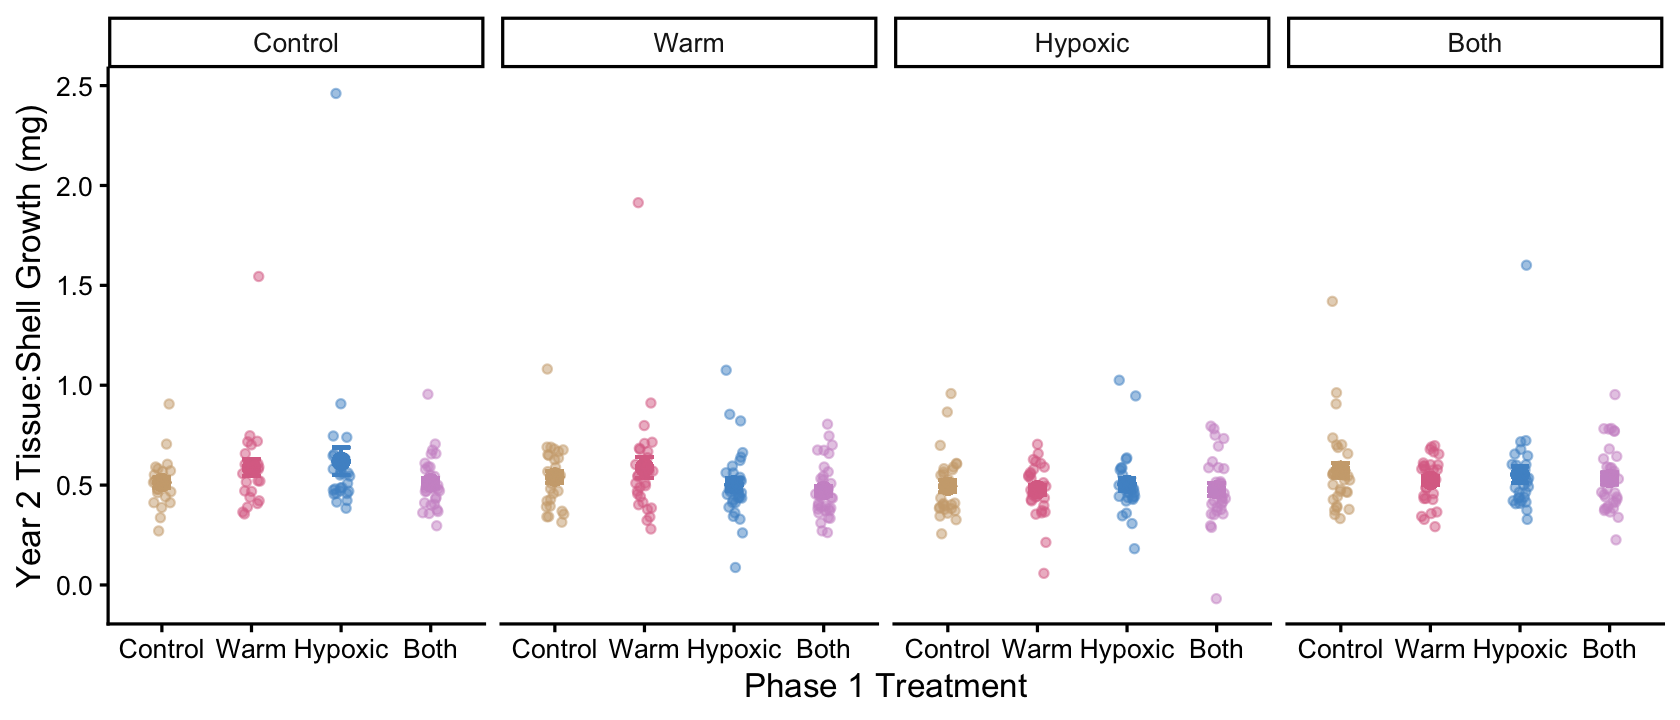

In [23]:
#format for :
options(repr.plot.width = 14, repr.plot.height = 6)

#all, TISSUE:SHELL
summary_stats_s <- low_TS %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(Ratio_TS_year2, na.rm = TRUE),
    se_growth = std.error(Ratio_TS_year2, na.rm = TRUE))

  #reorder Phase_1_treat and Phase_2_treat
  summary_stats_s$Phase_1_treat <- factor(summary_stats_s$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
  summary_stats_s$Phase_2_treat <- factor(summary_stats_s$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
  
  #plot with mean and SD, TISSUE:SHELL
  ggplot(summary_stats_s, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
    geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
    geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                  width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
geom_jitter(data = low_TS,
              aes(x = Phase_1_treat, y = Ratio_TS_year2, color = Phase_1_treat),
              width = 0.1, alpha = 0.5, size = 2) +
    theme_classic(base_size = 20) +
    guides(color = "none") + # Remove legend for color
    facet_wrap(vars(Phase_2_treat), 
               labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
               scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
    scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
    labs(x = "Phase 1 Treatment", y = "Year 2 Tissue:Shell Growth (mg)") +
    scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
    theme(legend.position = "none") # Remove legend

In [42]:
# need to find  and address this weird point for hypoxic both
    #2024_Hyp06_Both05_B59 has a Tissue:Shell of 7.32

In [24]:
max(Year2_Growth_clean$Ratio_TS_year2)

[1] 7.320282

In [ ]:
#2024_Hyp06_Both05_B59, no notes attached to this one
#can I exclude it just because its an outlier?

## statistical analysis

In [10]:

#THIS HAS FILTERED DATASET AS DATASET
m3 <- lmer(Ratio_TS_year2~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = low_TS, REML=TRUE)

#m4 <- lmer(Ratio_TS_year2~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+Actual_shell_pre_mg+
#             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
#             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Year2_Growth_clean, REML=TRUE)

#THIS HAS FILTERED DATASET AS DATASET
m5 <- lmer(Ratio_TS_year2~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+Actual_tissue_pre_mg+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = low_TS, REML=TRUE)

#m5 is the best covariate

#m6 <- lmer(Ratio_TS_year2~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+Actual_shell_post_mg+
#             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
#             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Year2_Growth_clean, REML=TRUE)

#m7 <- lmer(Ratio_TS_year2~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+Actual_tissue_post_mg+
#             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
#             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Year2_Growth_clean, REML=TRUE)

# AIC(m3, m4, m5, m6, m7)

boundary (singular) fit: see help('isSingular')

boundary (singular) fit: see help('isSingular')



In [11]:
aov_tab<-Anova(m3, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.241916e+03,1,17.75861,0.0000
Phase_1_DO,8.633612e-01,1,10.07705,0.3745
Phase_1_temp,6.286333e-01,1,12.82096,0.4423
Phase_2.1_temp,3.348863e-01,1,19.33339,0.5695
Phase_2.1_DO,5.544912e-01,1,19.34389,0.4654
Phase_1_DO:Phase_1_temp,2.938488e+00,1,10.11219,0.1169
Phase_1_DO:Phase_2.1_temp,2.068597e+00,1,18.73459,0.1669
Phase_1_temp:Phase_2.1_temp,1.228546e-02,1,18.95862,0.9129
Phase_1_DO:Phase_2.1_DO,6.002898e-01,1,18.75911,0.4481


In [13]:
#posthocs
emmeans(m3,specs = pairwise ~ Phase_1_DO*Phase_1_temp*Phase_2.1_DO, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_DO Phase_1_temp Phase_2.1_DO emmean     SE   df lower.CL upper.CL
 Hyp        Warm         Hyp           0.503 0.0304 44.9    0.441    0.564
 Norm       Warm         Hyp           0.504 0.0309 47.1    0.442    0.567
 Hyp        Ambient      Hyp           0.527 0.0314 48.5    0.464    0.591
 Norm       Ambient      Hyp           0.532 0.0307 45.3    0.470    0.594
 Hyp        Warm         Norm          0.488 0.0307 41.8    0.426    0.550
 Norm       Warm         Norm          0.582 0.0316 48.1    0.519    0.646
 Hyp        Ambient      Norm          0.559 0.0309 44.4    0.496    0.621
 Norm       Ambient      Norm          0.525 0.0329 53.3    0.460    0.591

Results are averaged over the levels of: Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                             estimate     SE   df t.ratio p.value
 Hyp Warm Hyp - Norm Warm Hyp         -0.00180 0.0351 25.9  -0.051  0.9596
 Hyp Warm Hyp - Hyp Ambie

In [34]:
aov_tab<-Anova(m4, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.761367e+02,1,90.39213,0.0000
Phase_1_DO,8.467446e-02,1,13.33746,0.7755
Phase_1_temp,1.203651e+00,1,13.33936,0.2920
Phase_2.1_temp,1.058446e+00,1,18.76468,0.3166
Phase_2.1_DO,1.117008e-02,1,18.79977,0.9169
Actual_shell_pre_mg,7.700140e-02,1,361.62843,0.7816
Phase_1_DO:Phase_1_temp,2.038839e+00,1,13.29428,0.1764
Phase_1_DO:Phase_2.1_temp,2.384727e-03,1,18.82103,0.9616
Phase_1_temp:Phase_2.1_temp,4.076342e-01,1,19.09178,0.5308


In [12]:
aov_tab<-Anova(m5, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),478.14989799,1,71.36206,0.0000
Phase_1_DO,0.54926116,1,10.04989,0.4756
Phase_1_temp,0.62481698,1,12.06880,0.4445
Phase_2.1_temp,0.35367891,1,19.02680,0.5590
Phase_2.1_DO,0.67541113,1,19.03963,0.4213
Actual_tissue_pre_mg,8.39624198,1,376.74684,0.0040
Phase_1_DO:Phase_1_temp,3.15343563,1,10.03568,0.1060
Phase_1_DO:Phase_2.1_temp,2.32715080,1,18.63058,0.1439
Phase_1_temp:Phase_2.1_temp,0.08734098,1,18.94560,0.7708


In [37]:
aov_tab<-Anova(m6, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.434592e+02,1,97.03730,0.0000
Phase_1_DO,1.191296e-01,1,13.73971,0.7352
Phase_1_temp,1.189050e+00,1,13.53471,0.2946
Phase_2.1_temp,1.087018e+00,1,18.67064,0.3104
Phase_2.1_DO,4.379796e-02,1,19.15616,0.8364
Actual_shell_post_mg,7.980121e-01,1,313.29456,0.3724
Phase_1_DO:Phase_1_temp,2.028057e+00,1,13.56922,0.1770
Phase_1_DO:Phase_2.1_temp,3.658445e-03,1,18.82505,0.9524
Phase_1_temp:Phase_2.1_temp,3.306779e-01,1,19.12647,0.5720


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,0.8481645,0.6234428
,457,NA,NA


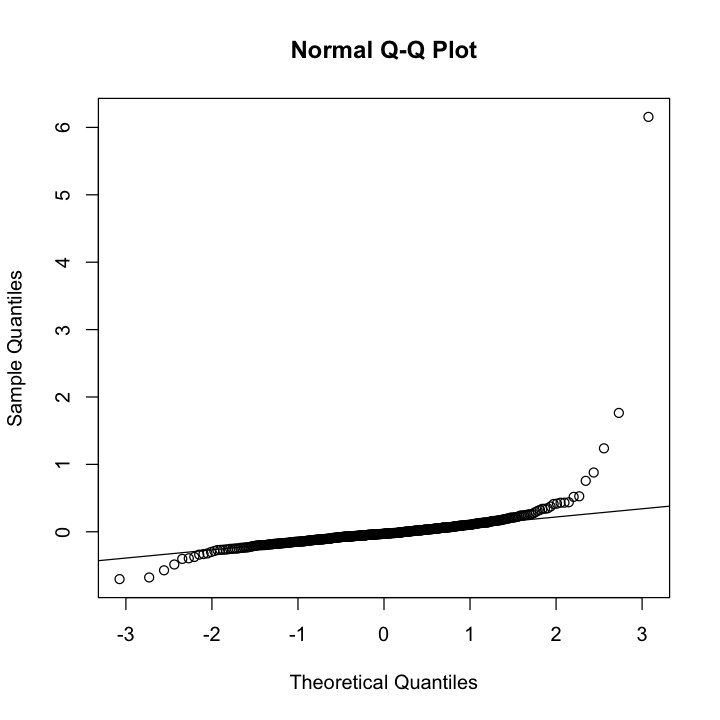

In [41]:
#format for jupyter
options(repr.plot.width = 6, repr.plot.height = 6)

leveneTest(Ratio_TS_year2~Phase_1_treat*Phase_2_treat, Year2_Growth_clean) 
m1.e <- residuals(m5) 
qqnorm(m1.e)
qqline(m1.e)

In [38]:
aov_tab<-Anova(m6, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.434592e+02,1,97.03730,0.0000
Phase_1_DO,1.191296e-01,1,13.73971,0.7352
Phase_1_temp,1.189050e+00,1,13.53471,0.2946
Phase_2.1_temp,1.087018e+00,1,18.67064,0.3104
Phase_2.1_DO,4.379796e-02,1,19.15616,0.8364
Actual_shell_post_mg,7.980121e-01,1,313.29456,0.3724
Phase_1_DO:Phase_1_temp,2.028057e+00,1,13.56922,0.1770
Phase_1_DO:Phase_2.1_temp,3.658445e-03,1,18.82505,0.9524
Phase_1_temp:Phase_2.1_temp,3.306779e-01,1,19.12647,0.5720


In [39]:
aov_tab<-Anova(m7, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.605838e+02,1,92.60608,0.0000
Phase_1_DO,9.819837e-02,1,13.56466,0.7588
Phase_1_temp,1.105493e+00,1,13.65720,0.3113
Phase_2.1_temp,1.038839e+00,1,18.75253,0.3211
Phase_2.1_DO,3.332730e-02,1,18.97137,0.8571
Actual_tissue_post_mg,1.139966e+00,1,368.78025,0.2864
Phase_1_DO:Phase_1_temp,2.001313e+00,1,13.47445,0.1799
Phase_1_DO:Phase_2.1_temp,1.214735e-03,1,18.81727,0.9726
Phase_1_temp:Phase_2.1_temp,3.739250e-01,1,18.91838,0.5482
